# TPE331 Modelica Transition Plan and Training
This notebook is a training guide to migrate the current turboprop Modelica model to a TPE331-oriented model.

Outputs:
- Practical migration plan (phased)
- Validation checklist and acceptance criteria
- Session-by-session training script

## 1) Target Architecture (what will change)
1. Compressor: replace/retune map scaling to TPE331 target.
2. Turbine: include two-map structure (GGT + FPT) and scale each map.
3. Shaft coupling: align gas-generator and power-turbine dynamics.
4. Fuel/control block: update schedule to match TPE331 operation envelope.
5. Validation harness: add map-level and cycle-level acceptance tests.

In [ ]:
import pandas as pd

plan_rows = [
    {"Phase": "P0", "Goal": "Baseline freeze", "Tasks": "Freeze current model, map files, and KPIs", "Deliverable": "Baseline package", "DoD": "Reproducible baseline run"},
    {"Phase": "P1", "Goal": "Compressor migration", "Tasks": "Apply TPE331 compressor scaling and wire to Modelica map block", "Deliverable": "Scaled compressor map", "DoD": "Design-point PR/flow/eta within tolerance"},
    {"Phase": "P2", "Goal": "Turbine migration", "Tasks": "Scale GGT/FPT XML maps and connect turbine blocks", "Deliverable": "Scaled turbine maps (GGT/FPT)", "DoD": "Stable turbine operating lines"},
    {"Phase": "P3", "Goal": "Cycle integration", "Tasks": "Re-tune shaft/load/nozzle interactions", "Deliverable": "Integrated TPE331 cycle model", "DoD": "No algebraic failure and stable transient"},
    {"Phase": "P4", "Goal": "Control adaptation", "Tasks": "Update fuel schedule, governor, limiters", "Deliverable": "Control-calibrated model", "DoD": "Step response and limit behavior pass"},
    {"Phase": "P5", "Goal": "Verification", "Tasks": "Run design/off-design sweeps and compare reference bands", "Deliverable": "Verification report", "DoD": "All acceptance criteria pass"},
]

plan_df = pd.DataFrame(plan_rows)
plan_df

## 2) Acceptance Criteria
Use these gates before claiming migration complete:
1. Map-level consistency:
   - Compressor and turbine design anchors are hit after scaling.
   - No non-physical map zones (negative efficiency, invalid PR).
2. Solver robustness:
   - No persistent initialization failures.
   - No unstable oscillation under nominal load steps.
3. Performance plausibility:
   - Power, flow, and key temperatures remain within expected range.
4. Traceability:
   - Every tuning value is logged with reason and evidence.

In [ ]:
checklist = [
    ("Compressor map scaled and wired", False),
    ("GGT map scaled and wired", False),
    ("FPT map scaled and wired", False),
    ("Shaft dynamics re-tuned", False),
    ("Fuel/governor schedule updated", False),
    ("Design point validation pass", False),
    ("Off-design sweep pass", False),
    ("Documentation and evidence pack ready", False),
]

check_df = pd.DataFrame(checklist, columns=["Item", "Done"])
check_df

## 3) Training Program (4 sessions)
### Session A - Map fundamentals and scaling
- Explain corrected vs actual flow.
- Re-run compressor and turbine scaling cells.
- Confirm design-anchor matching.

### Session B - Modelica block migration
- Replace map sources in Modelica blocks.
- Verify parameter wiring and package.order integrity.
- Run quick compile and initialization checks.

### Session C - Dynamics and controls
- Tune shaft inertia/load coupling and governor/fuel logic.
- Run transient scenarios (load step, fuel ramp).

### Session D - Verification and report
- Execute acceptance checklist.
- Capture plots/tables and create final migration report.

In [ ]:
session_plan = pd.DataFrame(
    [
        {"Session": "A", "Topic": "Map scaling", "Hands-on": "Run XML scaling and overlay plots", "Output": "Scaled map package"},
        {"Session": "B", "Topic": "Modelica wiring", "Hands-on": "Bind map tables to Modelica blocks", "Output": "Compilable migrated model"},
        {"Session": "C", "Topic": "Dynamics/control tuning", "Hands-on": "Tune transients and constraints", "Output": "Stable transient behavior"},
        {"Session": "D", "Topic": "Verification/report", "Hands-on": "Run sweeps and summarize evidence", "Output": "Validation report"},
    ]
)
session_plan

## 4) Practical Next Actions
1. In the map notebook, finalize TPE331 target values for compressor/GGT/FPT.
2. Export scaled maps to the format expected by the Modelica blocks.
3. Apply migration in small commits (map wiring, then control updates, then validation).
4. Use this notebook as the lecture script and sign-off checklist.

## Map-based Compressor/Turbine 이론 정리

이 섹션은 Modelica `CmpCharTable`/`TrbCharTable` 블록의 내부 동작을 이해하기 위한
맵 기반 터보기계 모델링 이론을 정리한 것입니다.

### 1) 상태 변수와 맵 좌표

Map-based 터보기계는 다음 2개 좌표를 기준으로 동작합니다:

- **보정 회전속도**: $N_{corr}$ (Nc)
- **보조 좌표**: $\beta \in [0,1]$ (또는 R-line)
  - $\beta=0$: choke 경계
  - $\beta=1$: surge 경계

맵 출력은 3개 스칼라 필드:
$$
\pi = \pi(N_{corr},\beta),\quad
\dot m_{corr}=\dot m_{corr}(N_{corr},\beta),\quad
\eta_{isen}=\eta_{isen}(N_{corr},\beta)
$$

### 2) 보정 유량/속도 정의

입구 조건 변화를 표준화하기 위해 보정량을 사용합니다:

$$
\dot m_{corr}=\dot m\cdot\frac{\sqrt{T_{in}/T_{ref}}}{p_{in}/p_{ref}}
$$

$$
N_{corr}=\frac{N}{\sqrt{T_{in}/T_{ref}}}
$$

역변환 (실제 유량 복원):
$$
\dot m = \dot m_{corr}\cdot\frac{p_{in}/p_{ref}}{\sqrt{T_{in}/T_{ref}}}
$$

> **Modelica 대응**: `CmpCharTable00`의 `NcTblDes`, `m_flow_1_des` 파라미터가 이 보정 관계를 정의합니다.

### 3) 맵 보간 및 경계 처리

격자점 $(N_i,\beta_j)$에서 연속 운전점 $(N_{corr},\beta)$로 확장:
- Modelica `CombiTable2D`가 bilinear interpolation 수행
- 경계 클램프: $\beta_{eff}=\min(1,\max(0,\beta))$

### 4) 압축기 열역학 관계

압력비 $\pi$가 맵에서 주어졌을 때:

$$T_{out,s} = T_{in}\cdot\pi^{(\gamma-1)/\gamma} \quad\text{(이상 출구온도)}$$

$$\Delta h_{isen}=c_p(T_{out,s}-T_{in}) \quad\text{(등엔트로피 엔탈피 상승)}$$

$$T_{out}=T_{in}+\frac{\Delta h_{isen}}{\eta_{isen}\cdot c_p} \quad\text{(실제 출구온도)}$$

축동력:
$$P_{shaft}=\frac{\dot m\cdot\Delta h_{isen}}{\eta_{isen}\cdot\eta_m}$$

토크:
$$\tau=\frac{P_{shaft}}{\omega}$$

> **Modelica 대응**: `CmpCharTable00` 내부에서 위 식이 `Wc→PR→eta→T_out→Power` 순서로 계산됩니다.

### 5) 설계점 스케일링 (Design-Point Anchoring)

XML 원본 맵을 목표 엔진에 맞추는 스케일링:

$$s_{Wc}=\frac{\dot m_{target,corr}}{Wc_{map,des}}, \quad s_{PR}=\frac{PR_{target}-1}{PR_{map,des}-1}, \quad s_\eta=\frac{\eta_{target}}{\eta_{map,des}}$$

스케일된 맵:
$$Wc_{scaled}=s_{Wc}\cdot Wc_{map}, \quad PR_{scaled}=1+s_{PR}(PR_{map}-1), \quad \eta_{scaled}=s_\eta\cdot\eta_{map}$$

> **Modelica 대응**: `NmechDes`, `PRdes`, `effDes`, `m_flow_1_des` 파라미터가 이 스케일링을 수행합니다.

### 6) 보존식 및 수치 안정화

질량 보존: $\dot m_{in}+\dot m_{out}=0$

에너지 보존: $\dot m(h_{out}-h_{in}) = P_{fluid}$

수치 안정화:
- $\eta_{isen}\ge \eta_{min}>0$ (효율 하한 제한)
- 압력비 하한: $\pi\ge 1$ (압축기 모드)
- 맵 경계 스무딩: $\beta_{sm}=\frac{1}{2}\left[1+\tanh\left(\frac{\beta-\beta_0}{\epsilon}\right)\right]$

# Map Visualization 

## 5) TPE331 Map Visualization (turbomap utils)

패키지화된 유틸리티:
- `turbomap_data_utils.py` — XML 파싱 + 설계점 스케일링
  - `parse_compressor_xml(path)` / `parse_turbine_xml(path)`
  - `scale_compressor_map(parsed, target)` / `scale_turbine_map(parsed, target)`
- `turbomap_plot_utils.py` — 시각화 함수
  - `plot_compressor_map()` — 단독 맵 (surge/choke/rpm/eff contours)
  - `plot_compressor_overlay()` — base vs scaled 2-panel 비교

In [2]:
import sys, os, importlib
import numpy as np

# notebooks/ → turbomap/ (parent dir has utility modules)
_TURBOMAP_DIR = os.path.normpath(os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))
if _TURBOMAP_DIR not in sys.path:
    sys.path.insert(0, _TURBOMAP_DIR)

import turbomap_data_utils, turbomap_plot_utils
importlib.reload(turbomap_data_utils)
importlib.reload(turbomap_plot_utils)

from turbomap_data_utils import parse_compressor_xml, scale_compressor_map, T_REF, P_REF
from turbomap_plot_utils import plot_compressor_map, plot_compressor_overlay

# ─── 1) XML 파싱 + TPE331 스케일링 ───
xml_cmp_path = r"C:\Users\user\Downloads\Turboprop_ggc.xml"

cmp_parsed = parse_compressor_xml(xml_cmp_path)
print(f"XML loaded: {cmp_parsed['path']}")
print(f"  Nc range: {cmp_parsed['nc'].min():.3f} ~ {cmp_parsed['nc'].max():.3f}")
print(f"  Design anchor: Nc={cmp_parsed['nc_des']:.4f}, Rline={cmp_parsed['rline_des']:.5f}")
print(f"  Wc_des={cmp_parsed['wc_des']:.4f}, PR_des={cmp_parsed['pr_des']:.4f}, eta_des={cmp_parsed['eta_des']:.4f}")

# TPE331 compressor target
TPE331_CMP = {
    "m_flow_des": 8.0,      # kg/s (actual)
    "PRdes": 10.0,           # pressure ratio
    "effDes": 0.82,          # efficiency
    "T1_des": 288.15,        # K
    "p1_des": 101325.0,      # Pa
}

scaled = scale_compressor_map(cmp_parsed, TPE331_CMP)
print(f"\n[Scale factors]")
print(f"  s_Wc(actual)={scaled['s_Wc_actual']:.6f}, s_Wc(corr)={scaled['s_Wc_corr']:.6f}")
print(f"  s_PR={scaled['s_PR']:.6f}, s_eff={scaled['s_eff']:.6f}")
print(f"  Wc target corrected={scaled['wc_target_corr']:.4f} kg/s")

# ─── Correction factor 진단 ───
corr_factor = np.sqrt(TPE331_CMP["T1_des"] / T_REF) / (TPE331_CMP["p1_des"] / P_REF)
print(f"\n[Correction factor diagnostic]")
print(f"  T1_des/T_REF = {TPE331_CMP['T1_des']:.2f}/{T_REF:.2f} = {TPE331_CMP['T1_des']/T_REF:.6f}")
print(f"  p1_des/P_REF = {TPE331_CMP['p1_des']:.1f}/{P_REF:.1f} = {TPE331_CMP['p1_des']/P_REF:.6f}")
print(f"  Wc_corr = m_dot × sqrt(T/Tref) / (P/Pref)  →  correction factor = {corr_factor:.6f}")


XML loaded: C:\Users\user\Downloads\Turboprop_ggc.xml
  Nc range: 0.500 ~ 1.050
  Design anchor: Nc=0.9500, Rline=0.52632
  Wc_des=31.0260, PR_des=7.6067, eta_des=0.8668

[Scale factors]
  s_Wc(actual)=0.257849, s_Wc(corr)=0.257849
  s_PR=1.362264, s_eff=0.945965
  Wc target corrected=8.0000 kg/s

[Correction factor diagnostic]
  T1_des/T_REF = 288.15/288.15 = 1.000000
  p1_des/P_REF = 101325.0/101325.0 = 1.000000
  Wc_corr = m_dot × sqrt(T/Tref) / (P/Pref)  →  correction factor = 1.000000


✓ plot_compressor_map() with real XML data


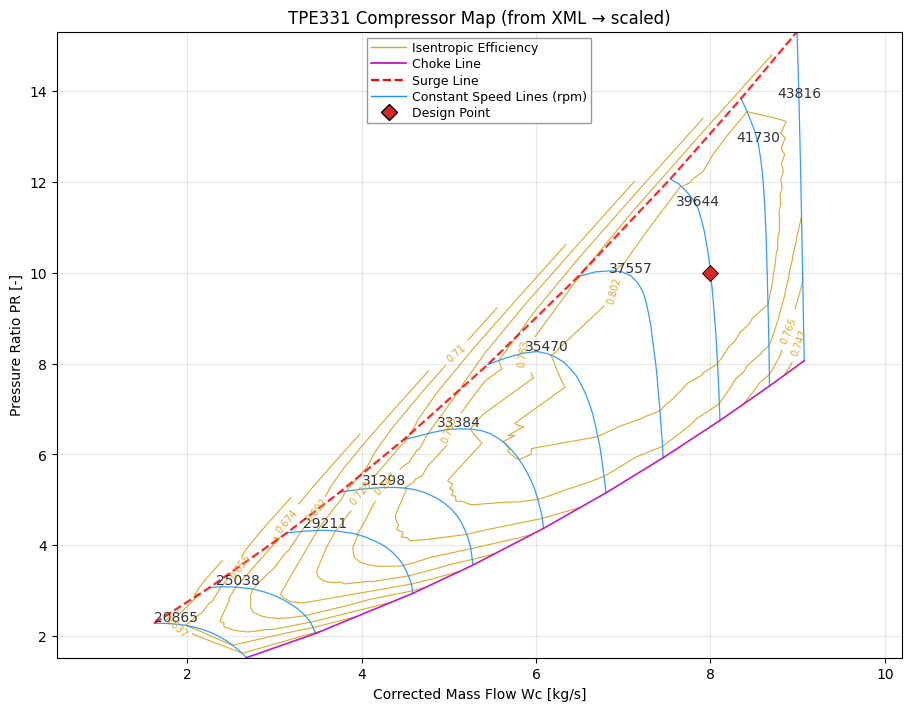

In [3]:
# ─── 2) 단독 컴프레서 맵 시각화 (Cell-40 style) ───
fig1, ax1 = plot_compressor_map(
    scaled["wc_scaled_corr"],
    scaled["pr_scaled"],
    scaled["eta_scaled"],
    scaled["nc"],
    NmechDes=41730.0,  # TPE331 gas generator ~41730 rpm
    design_point={"Wc": scaled["wc_target_corr"], "PR": TPE331_CMP["PRdes"]},
    title="TPE331 Compressor Map (from XML → scaled)",
)
print("✓ plot_compressor_map() with real XML data")

✓ plot_compressor_overlay() — base map hidden


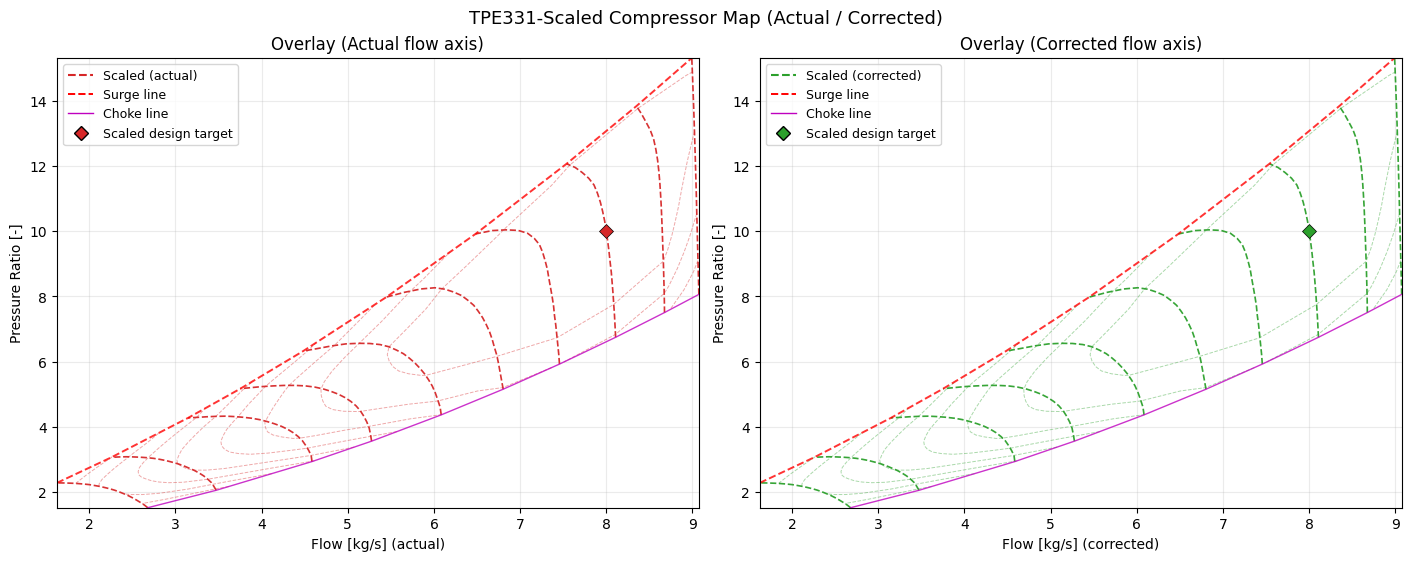

In [4]:
# ─── 3) Base vs Scaled 오버레이 (Cell-42 style) ───
# "Base" = XML 원본 맵 (unscaled), "Scaled" = TPE331으로 스케일된 맵
fig2, axes2 = plot_compressor_overlay(
    Wc_base=cmp_parsed["wc"],
    PR_base=cmp_parsed["pr"],
    Eta_base=cmp_parsed["eta"],
    Nc_base=cmp_parsed["nc"],
    Wc_scaled_actual=scaled["wc_scaled_actual"],
    Wc_scaled_corr=scaled["wc_scaled_corr"],
    PR_scaled=scaled["pr_scaled"],
    Eta_scaled=scaled["eta_scaled"],
    Nc_scaled=scaled["nc"],
    show_base=False,
    base_design=None,
    scaled_design_actual={"Wc": TPE331_CMP["m_flow_des"], "PR": TPE331_CMP["PRdes"]},
    scaled_design_corr={"Wc": scaled["wc_target_corr"], "PR": TPE331_CMP["PRdes"]},
    suptitle="TPE331-Scaled Compressor Map (Actual / Corrected)",
)
print("✓ plot_compressor_overlay() — base map hidden")

## 6) Turbine Map Visualization (TPE331 Single Turbine)

TPE331은 단축 터보프롭 — 터빈 3단이 컴프레서+프로펠러를 동시 구동 (PR≈8).
GGT XML을 기반으로 PR=8 설계점으로 스케일링.

- `parse_turbine_xml(path)` → XML 파싱
- `scale_turbine_map(parsed, target)` → 설계점 스케일링
- `plot_turbine_maps_2x2(scaled_maps)` → Wc/η vs PR 레이아웃

In [5]:
# ─── 4) Turbine XML 파싱 + TPE331 스케일링 (단축 터빈, PR=8) ───
importlib.reload(turbomap_data_utils)
importlib.reload(turbomap_plot_utils)

from turbomap_data_utils import parse_turbine_xml, scale_turbine_map
from turbomap_plot_utils import plot_turbine_maps_2x2

# TPE331: 단축 3단 터빈 (GGT XML 기반, PR=8으로 스케일)
xml_trb_path = r"C:\Users\user\Downloads\Turboprop_ggt_Rline.xml"

TPE331_TRB_TARGET = {
    "m_flow_des": 8.0,       # kg/s
    "PRdes": 8.0,            # total expansion ratio (single turbine)
    "effDes": 0.87,          # 3-stage turbine efficiency
    "T1_des": 1200.0,        # K (TIT)
    "p1_des": 400000.0,      # Pa (after combustor, ~10*p_inlet at altitude)
}

parsed_trb = parse_turbine_xml(xml_trb_path)
scaled_trb_single = scale_turbine_map(parsed_trb, TPE331_TRB_TARGET)
scaled_trb_single["target"] = TPE331_TRB_TARGET

print(f"[TPE331 Turbine] XML: {parsed_trb['path']}")
print(f"  Nc range: {parsed_trb['nc'].min():.3f} ~ {parsed_trb['nc'].max():.3f}")
print(f"  s_Wc_corr={scaled_trb_single['s_Wc_corr']:.4f}")
print(f"  s_PR={scaled_trb_single['s_PR']:.4f}")
print(f"  s_eff={scaled_trb_single['s_eff']:.4f}")
print(f"  Wc_target_corr={scaled_trb_single['wc_target_corr']:.4f} kg/s")

# plot_turbine_maps_2x2 호환용 dict (키 1개)
scaled_trb = {"Trb": scaled_trb_single}

[TPE331 Turbine] XML: C:\Users\user\Downloads\Turboprop_ggt_Rline.xml
  Nc range: 0.600 ~ 1.100
  s_Wc_corr=1.3252
  s_PR=4.1637
  s_eff=0.9554
  Wc_target_corr=4.1355 kg/s


✓ TPE331 turbine map — single shaft, PR=8


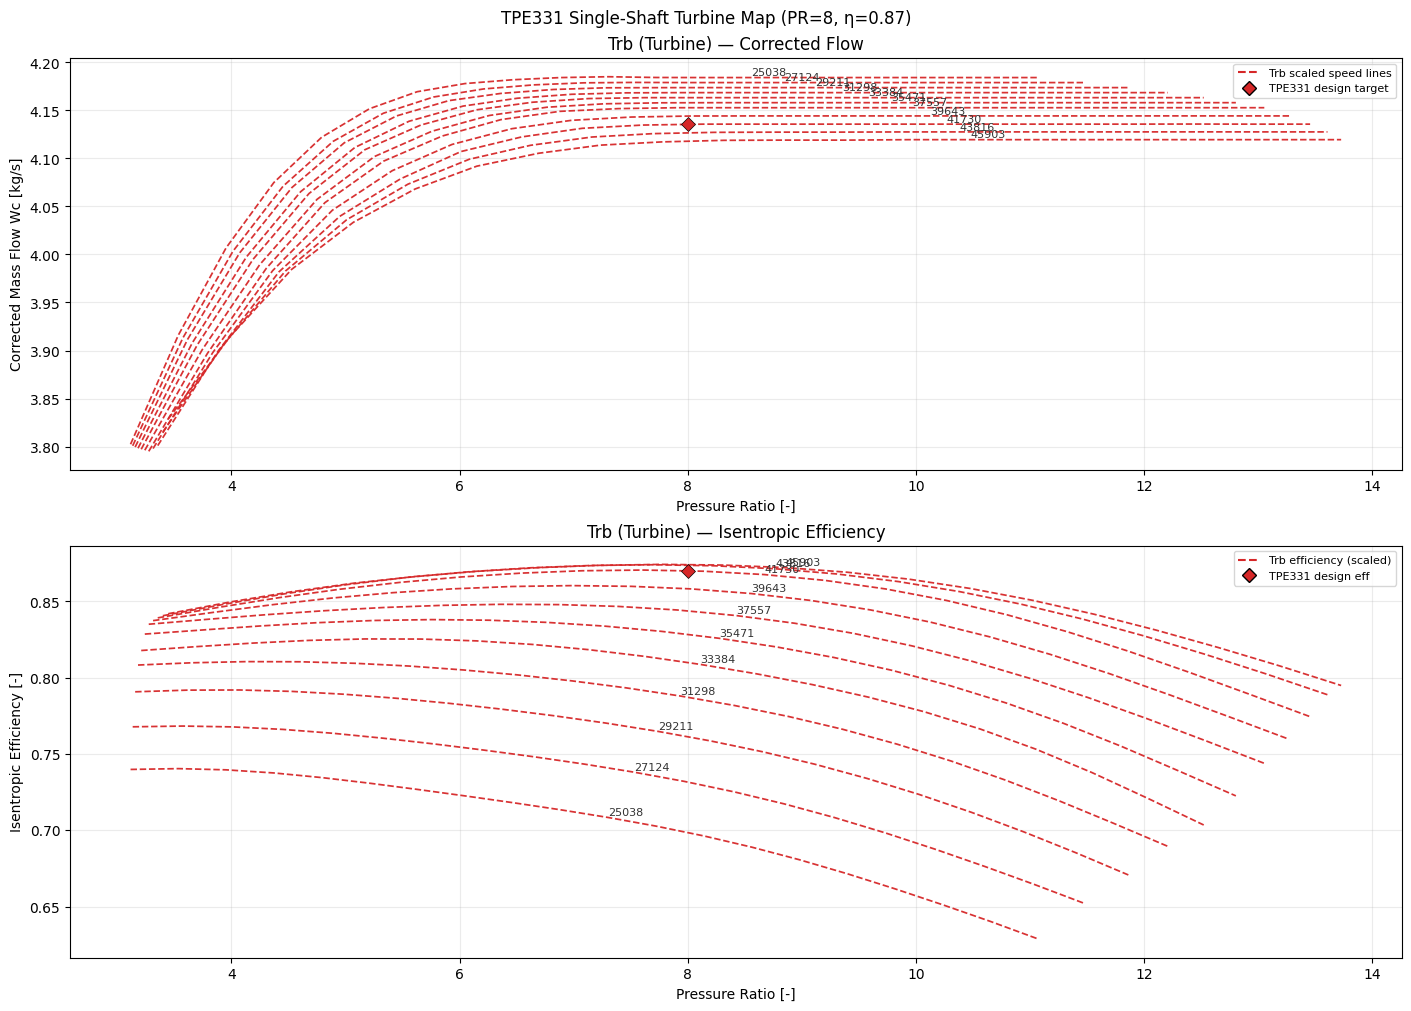

In [6]:
# ─── 5) Turbine Map Plot (TPE331 single turbine, PR=8) ───
fig3, axes3 = plot_turbine_maps_2x2(
    scaled_trb,
    suptitle="TPE331 Single-Shaft Turbine Map (PR=8, η=0.87)",
    NmechDes_dict={"Trb": 41730.0},
)
print("✓ TPE331 turbine map — single shaft, PR=8")

# Modeling

## 7) Modelica Table Export & .mo Patch (backend packages)

패키지:
- `modelica_table_exporter.py` — 스케일된 맵 → Modelica CombiTable2D `.txt` 파일
- `mo_param_patcher.py` — `.mo` 파일 설계점 파라미터 regex 패치

검증: PropulsionSystem 기존 테이블 포맷과 동일한 구조가 생성되는지 확인

In [ ]:
# ─── 6) Modelica Table Export 검증 ───
# turbomap 경로는 이미 위에서 추가됨 (_TURBOMAP_DIR)

import modelica_table_exporter
importlib.reload(modelica_table_exporter)
from modelica_table_exporter import (
    export_compressor_tables,
    export_turbine_tables_from_rline,
)

# ━━━ 아키텍처 선택 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ARCHITECTURE = "single"   # "single" = TPE331 단축  |  "twin" = 2축 (GGT+FPT)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# --- Compressor table export (공통) ---
out_cmp = export_compressor_tables(
    nc=scaled["nc"],
    rline=scaled["rline"],
    wc=scaled["wc_scaled_corr"],
    pr=scaled["pr_scaled"],
    eff=scaled["eta_scaled"],
    output_path=r"d:\KangDH\ModelicaLib\PropulsionSystem\tableData\table_Compressor_WcPReff_NcRline_TPE331.txt",
)
print(f"✓ Compressor table exported: {out_cmp}")
print(f"  Shape: nc={len(scaled['nc'])}, rline={len(scaled['rline'])}")
print(f"  → Modelica: Wc_NcRline({len(scaled['nc'])+1},{len(scaled['rline'])+1})")

if ARCHITECTURE == "single":
    # ─── 단축 (TPE331): 터빈 1개, PR=8 ───
    trb = scaled_trb["Trb"]
    result_trb = export_turbine_tables_from_rline(
        nc=trb["nc"],
        pr_scaled=trb["pr_scaled"],
        wc=trb["wc_scaled_corr"],
        eff=trb["eta_scaled"],
        output_path=r"d:\KangDH\ModelicaLib\PropulsionSystem\tableData\table_Turbine_WcEff_NcPR_TPE331_Trb.txt",
        n_pr_points=20,
    )
    print(f"\n✓ Turbine table exported (single-shaft): {result_trb['path']}")
    print(f"  PR axis: {result_trb['pr_axis'].min():.3f} ~ {result_trb['pr_axis'].max():.3f}")
    print(f"  PRtblDes (auto): {result_trb['pr_des_approx']:.4f}")
    print(f"\n{'='*60}")
    print(f"  Modelica PRtblDes_paramInput = {result_trb['pr_des_approx']:.4f}")
    print(f"  (→ TurboProp_TPE331_ex01b.mo 에 설정)")
    print(f"{'='*60}")

elif ARCHITECTURE == "twin":
    # ─── 2축 (GGT + FPT) ───
    ggt = scaled_trb["GGT"]
    result_ggt = export_turbine_tables_from_rline(
        nc=ggt["nc"],
        pr_scaled=ggt["pr_scaled"],
        wc=ggt["wc_scaled_corr"],
        eff=ggt["eta_scaled"],
        output_path=r"d:\KangDH\ModelicaLib\PropulsionSystem\tableData\table_Turbine_WcEff_NcPR_TPE331_GGT.txt",
        n_pr_points=20,
    )
    print(f"\n✓ GGT turbine table exported: {result_ggt['path']}")
    print(f"  PR axis: {result_ggt['pr_axis'].min():.3f} ~ {result_ggt['pr_axis'].max():.3f}")
    print(f"  PRtblDes (auto): {result_ggt['pr_des_approx']:.4f}")

    fpt = scaled_trb["FPT"]
    result_fpt = export_turbine_tables_from_rline(
        nc=fpt["nc"],
        pr_scaled=fpt["pr_scaled"],
        wc=fpt["wc_scaled_corr"],
        eff=fpt["eta_scaled"],
        output_path=r"d:\KangDH\ModelicaLib\PropulsionSystem\tableData\table_Turbine_WcEff_NcPR_TPE331_FPT.txt",
        n_pr_points=20,
    )
    print(f"\n✓ FPT turbine table exported: {result_fpt['path']}")
    print(f"  PR axis: {result_fpt['pr_axis'].min():.3f} ~ {result_fpt['pr_axis'].max():.3f}")
    print(f"  PRtblDes (auto): {result_fpt['pr_des_approx']:.4f}")

    print(f"\n{'='*60}")
    print(f"  Modelica PRtblDes_paramInput (자동 산출)")
    print(f"{'='*60}")
    print(f"  GGT: PRtblDes = {result_ggt['pr_des_approx']:.4f}")
    print(f"  FPT: PRtblDes = {result_fpt['pr_des_approx']:.4f}")
    print(f"  (→ TurboProp_TPE331_ex01.mo 에 설정)")

else:
    raise ValueError(f"ARCHITECTURE must be 'single' or 'twin', got '{ARCHITECTURE}'")

# --- 생성된 컴프레서 파일 첫 5줄 확인 ---
print("\n─── Compressor table (head) ───")
with open(out_cmp) as f:
    for i, line in enumerate(f):
        if i >= 5: break
        print(line.rstrip())

## 8) TPE331 Transient Modelica Model (Turbojet_ex01 기반)

`Turbojet_ex01` 구조를 확장한 2축 터보프롭 모델 (프로펠러 없음):

```
Flt2Fluid → Inlet → Cmp(TPE331) → Comb → GGT → FPT → Nzl
                         ↕ GG shaft        ↕ PT shaft + LoadTorque
```

| 컴포넌트 | 설계점 | 테이블 파일 |
|----------|--------|------------|
| Cmp | 41730rpm, PR=10, η=0.82, 8kg/s | `table_Compressor_WcPReff_NcRline_TPE331.txt` |
| GGT | 41730rpm, T1=1200K, 8.2kg/s | `table_Turbine_WcEff_NcPR_TPE331_GGT.txt` |
| FPT | 30000rpm, T1=1000K, 8.2kg/s | `table_Turbine_WcEff_NcPR_TPE331_FPT.txt` |

**입력 신호:**
- 연료 유량 Ramp: 0.15 → 0.17 kg/s (t=10~15s)
- PT 부하 토크 Ramp: -200 → -700 N⋅m (t=20~25s)

**파일:** `PropulsionSystem/Examples/Engines/Transient/TurboProp_TPE331_ex01.mo`

## 9) Ex01a 결과 검증 (Gas Generator Single-Spool)

`TurboProp_TPE331_ex01a`: Cmp + Comb + GGT + Nzl (FPT 없음, 터보젯 구성)  
`tb_postproc.TBPostProcessor`를 사용하여 결과 로딩 + 플롯 + 파워밸런스 검증.

In [ ]:
from tb_postproc import TBPostProcessor

# ── TB 연결 & 신호 탐색 ──
pp = TBPostProcessor(
    project=r"E:\KDH\simTemp\TB\Turbo.aedt",
    design="TPE331_ex1a",
    aedt_version="2026.1",
)
pp.connect()
signals = pp.discover_signals()
print(f"\nKey signals: {len(signals)}")
for s in signals[:20]:
    print(f"  {s}")

In [ ]:
# ── 시계열 수집 ──
mdf = pp.collect_signals()
print(f"\nColumns ({len(mdf.columns)-1} signals):")
for c in sorted(mdf.columns):
    if c != "time":
        print(f"  {c}")

In [ ]:
# ── 과도응답 플롯 ──
fig = pp.plot_transient(J_shaft=0.5, title="TPE331 ex01a — GG Single Spool")

In [ ]:
# ── 정량 검증: 파워밸런스 & 정상상태 값 ──
vr = pp.verify_power_balance(J_shaft=0.5, ss_fraction=0.1)

# 설계점 비교
print("\n--- Design Point Comparison ---")
des = {"shaft_rpm": 41730.0, "PR_cmp": 10.0, "eff_cmp": 0.82}
for k, v_des in des.items():
    v_sim = vr.steady_state.get(k)
    if v_sim is not None:
        err_pct = (v_sim - v_des) / v_des * 100
        print(f"  {k:14s}: design={v_des:.2f}, sim={v_sim:.2f}, err={err_pct:+.2f}%")

In [ ]:
# ── 컴프레서 맵 + 시뮬레이션 운전 궤적 오버레이 ──
import matplotlib.pyplot as plt
from turbomap_plot_utils import plot_compressor_map

# 시뮬레이션에서 Wc, PR, Nc 추출
col_Wc = pp.find_col(["Cmp_Wc_1", "Cmp_Wc"])
col_PR = pp.find_col(["Cmp_PR"])
col_Nc = pp.find_col(["Cmp_Nc_1", "Cmp_Nc"])

print(f"Wc col: {col_Wc}")
print(f"PR col: {col_PR}")
print(f"Nc col: {col_Nc}")

if col_Wc and col_PR:
    t_sim = mdf["time"].to_numpy()
    Wc_sim = mdf[col_Wc].to_numpy(dtype=float)
    PR_sim = mdf[col_PR].to_numpy(dtype=float)

    # 1) 컴프레서 맵 그리기 (기존 스케일된 맵)
    fig_ov, ax_ov = plot_compressor_map(
        scaled["wc_scaled_corr"],
        scaled["pr_scaled"],
        scaled["eta_scaled"],
        scaled["nc"],
        NmechDes=41730.0,
        design_point={"Wc": scaled["wc_target_corr"], "PR": TPE331_CMP["PRdes"]},
        title="TPE331 Compressor Map + Sim Operating Trajectory",
    )

    # 2) 시뮬레이션 궤적 오버레이 (시간 색상 코딩)
    sc = ax_ov.scatter(
        Wc_sim, PR_sim, c=t_sim, cmap="plasma", s=8, zorder=5, alpha=0.7, edgecolors="none"
    )
    cbar = plt.colorbar(sc, ax=ax_ov, shrink=0.8, pad=0.02)
    cbar.set_label("Time [s]")

    # 시작/종료점 강조
    ax_ov.plot(Wc_sim[0], PR_sim[0], "g^", ms=12, zorder=6, label=f"t={t_sim[0]:.1f}s (start)")
    ax_ov.plot(Wc_sim[-1], PR_sim[-1], "rs", ms=12, zorder=6, label=f"t={t_sim[-1]:.1f}s (end)")
    ax_ov.legend(loc="lower right", fontsize=9)

    plt.show()
    print(f"✓ Operating trajectory: Wc={Wc_sim[0]:.2f}→{Wc_sim[-1]:.2f}, PR={PR_sim[0]:.2f}→{PR_sim[-1]:.2f}")
else:
    print("⚠ Wc_1 또는 PR 컬럼이 mdf에 없습니다. 사용 가능한 컬럼:")
    for c in sorted(mdf.columns):
        if c != "time":
            print(f"  {c}")

In [ ]:
# ── GGT 터빈 맵 + 시뮬레이션 운전 궤적 오버레이 (plot_turbine_maps_2x2 재사용) ──
import numpy as np
import matplotlib.pyplot as plt
from turbomap_plot_utils import plot_turbine_maps_2x2

# 시뮬레이션에서 GGT 신호 추출
col_GGT_Wc = pp.find_col(["GGT_Wc_1", "GGT_Wc"])
col_GGT_PR = pp.find_col(["GGT_PR"])
col_GGT_Eta = pp.find_col(["GGT_eff", "GGT_eta"])

print(f"GGT Wc col : {col_GGT_Wc}")
print(f"GGT PR col : {col_GGT_PR}")
print(f"GGT Eta col: {col_GGT_Eta}")

if col_GGT_Wc and col_GGT_PR:
    t_sim = mdf["time"].to_numpy()
    Wc_ggt = mdf[col_GGT_Wc].to_numpy(dtype=float)
    PR_ggt = mdf[col_GGT_PR].to_numpy(dtype=float)
    Eta_ggt = mdf[col_GGT_Eta].to_numpy(dtype=float) if col_GGT_Eta else None

    # 1) 기존 plot_turbine_maps_2x2() 호출 → (fig, axes) 반환
    fig_t, axes_t = plot_turbine_maps_2x2(
        scaled_trb,
        suptitle="TPE331 Turbine Map + Sim Operating Trajectory",
        NmechDes_dict={"GGT": 41730.0, "FPT": 30000.0},
    )

    # 2) GGT axes에 시뮬레이션 궤적 오버레이
    # axes_t[0, col] = Wc vs PR,  axes_t[1, col] = Eta vs PR
    # GGT는 첫 번째 컬럼 (col=0)
    ax_wc = axes_t[0, 0]   # top-left: x=PR, y=Wc
    ax_eta = axes_t[1, 0]  # bottom-left: x=PR, y=Eta

    # Wc trajectory
    sc_wc = ax_wc.scatter(PR_ggt, Wc_ggt, c=t_sim, cmap="plasma", s=10, zorder=6, alpha=0.8, edgecolors="none")
    plt.colorbar(sc_wc, ax=ax_wc, shrink=0.7, pad=0.02, label="Time [s]")
    ax_wc.plot(PR_ggt[0], Wc_ggt[0], "g^", ms=11, zorder=7, label=f"t={t_sim[0]:.2f}s")
    ax_wc.plot(PR_ggt[-1], Wc_ggt[-1], "rs", ms=11, zorder=7, label=f"t={t_sim[-1]:.2f}s")
    ax_wc.legend(loc="best", fontsize=7)

    # Eta trajectory (if available)
    if Eta_ggt is not None:
        sc_eta = ax_eta.scatter(PR_ggt, Eta_ggt, c=t_sim, cmap="plasma", s=10, zorder=6, alpha=0.8, edgecolors="none")
        plt.colorbar(sc_eta, ax=ax_eta, shrink=0.7, pad=0.02, label="Time [s]")
        ax_eta.plot(PR_ggt[0], Eta_ggt[0], "g^", ms=11, zorder=7)
        ax_eta.plot(PR_ggt[-1], Eta_ggt[-1], "rs", ms=11, zorder=7)

    plt.show()
    print(f"✓ GGT trajectory overlaid: PR={PR_ggt[0]:.2f}→{PR_ggt[-1]:.2f}, Wc={Wc_ggt[0]:.3f}→{Wc_ggt[-1]:.3f}")
else:
    print("⚠ GGT_Wc 또는 GGT_PR 컬럼 없음. 사용 가능:")
    for c in sorted(mdf.columns):
        if "GGT" in c.upper():
            print(f"  {c}")

## 10) Ex01b 결과 검증 (Single-Shaft + Propeller Load)

`TurboProp_TPE331_ex01b`: Cmp + Comb + Trb(PR=8) + Nzl, 단일축 + 프로펠러 부하 (기어비 환산)
- Idle 부하 -23 N·m → Cruise -114 N·m (t=20~25s ramp)
- 축 속도 droop, TIT 응답, 컴프레서 운전점 이동 관측

In [21]:
from tb_postproc import TBPostProcessor

# ── TB 연결 & 신호 탐색 (ex01b) ──
pp_b = TBPostProcessor(
    project=r"E:\KDH\simTemp\TB\Turbo.aedt",
    design="TPE331_ex1b",
    aedt_version="2026.1",
)
pp_b.connect()
signals_b = pp_b.discover_signals()
print(f"\nKey signals (ex01b): {len(signals_b)}")
for s in signals_b[:25]:
    print(f"  {s}")

PyAEDT INFO: Parsing E:\KDH\simTemp\TB\Turbo.aedt.
PyAEDT INFO: Python version 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)].
PyAEDT INFO: PyAEDT version 1.0.0rc2.
PyAEDT INFO: Returning found Desktop session with PID 3620!
PyAEDT INFO: File E:\KDH\simTemp\TB\Turbo.aedt correctly loaded. Elapsed time: 0m 30sec
PyAEDT INFO: Project Turbo set to active.
PyAEDT INFO: Active Design set to 15;TPE331_ex1b
PyAEDT INFO: AEDT objects correctly read
Connected: Turbo / TPE331_ex1b
PyAEDT INFO: Post class has been initialized! Elapsed time: 0m 0sec
Total expressions: 2762
After exclusion: 1526 (removed 1236 internal)
Selected key signals: 131

Key signals (ex01b): 131
  ex01b1.Cmp_CmpTbl_WcPReff_NcRline_y_PR
  ex01b1.Cmp_CmpTbl_WcPReff_NcRline_y_eff
  ex01b1.Cmp_Nc_1
  ex01b1.Cmp_NcqNcDes_1
  ex01b1.Cmp_Nmech
  ex01b1.Cmp_NqNdes
  ex01b1.Cmp_PR
  ex01b1.Cmp_Rline
  ex01b1.Cmp_ScalerDesCmp_CmpTbl_WcPReff_NcRline_Des_y_PR
  ex01b1.Cmp_ScalerDesCmp_CmpTbl_WcPReff_Nc

In [22]:
# ── 시계열 수집 (ex01b) ──
mdf_b = pp_b.collect_signals()
print(f"\nColumns ({len(mdf_b.columns)-1} signals):")
for c in sorted(mdf_b.columns):
    if c != "time":
        print(f"  {c}")

PyAEDT WARNING: No report category provided. Automatically identified Standard
PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec
PyAEDT WARNING: No report category provided. Automatically identified Standard


c:\Users\user\.ansys_python_venvs\pyAEDT_py311\Lib\site-packages\ansys\aedt\core\visualization\post\solution_data.py:648: UserWarning: Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.
  warnings.warn("Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.")


PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec
PyAEDT WARNING: No report category provided. Automatically identified Standard


c:\Users\user\.ansys_python_venvs\pyAEDT_py311\Lib\site-packages\ansys\aedt\core\visualization\post\solution_data.py:648: UserWarning: Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.
  warnings.warn("Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.")


PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec
PyAEDT WARNING: No report category provided. Automatically identified Standard


...

c:\Users\user\.ansys_python_venvs\pyAEDT_py311\Lib\site-packages\ansys\aedt\core\visualization\post\solution_data.py:648: UserWarning: Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.
  warnings.warn("Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.")


PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec
PyAEDT WARNING: No report category provided. Automatically identified Standard


c:\Users\user\.ansys_python_venvs\pyAEDT_py311\Lib\site-packages\ansys\aedt\core\visualization\post\solution_data.py:648: UserWarning: Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.
  warnings.warn("Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.")


PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec
Time axis: ns -> s (raw span=2.97e+10 ns = 29.71 s)
Collected: 2984 steps, 131 signals (0 missing)

Columns (131 signals):
  ex01b1.Cmp_CmpTbl_WcPReff_NcRline_y_PR
  ex01b1.Cmp_CmpTbl_WcPReff_NcRline_y_eff
  ex01b1.Cmp_Nc_1
  ex01b1.Cmp_NcqNcDes_1
  ex01b1.Cmp_Nmech
  ex01b1.Cmp_NqNdes
  ex01b1.Cmp_PR
  ex01b1.Cmp_Rline
  ex01b1.Cmp_ScalerDesCmp_CmpTbl_WcPReff_NcRline_Des_y_PR
  ex01b1.Cmp_ScalerDesCmp_CmpTbl_WcPReff_NcRline_Des_y_eff
  ex01b1.Cmp_SclCmp_u_PR
  ex01b1.Cmp_SclCmp_u_eff
  ex01b1.Cmp_SclCmp_u_s_PR
  ex01b1.Cmp_SclCmp_u_s_eff
  ex01b1.Cmp_Wc_1
  ex01b1.Cmp_eff
  ex01b1.Cmp_flange_1_des_Nmech
  ex01b1.Cmp_flange_1_des_omega
  ex01b1.Cmp_flange_1_des_pwr
  ex01b1.Cmp_flange_1_des_trq
  ex01b1.Cmp_flange_2_des_Nmech
  ex01b1.Cmp_flange_2_des_omega
  ex01b1.Cmp_flange_2_des_pwr
  ex01b1.Cmp_flange_2_des_trq
  ex01b1.Cmp_fluid_1_T
  ex01b1.Cmp_fluid_1_des_

c:\Users\user\.ansys_python_venvs\pyAEDT_py311\Lib\site-packages\ansys\aedt\core\visualization\post\solution_data.py:648: UserWarning: Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.
  warnings.warn("Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.")


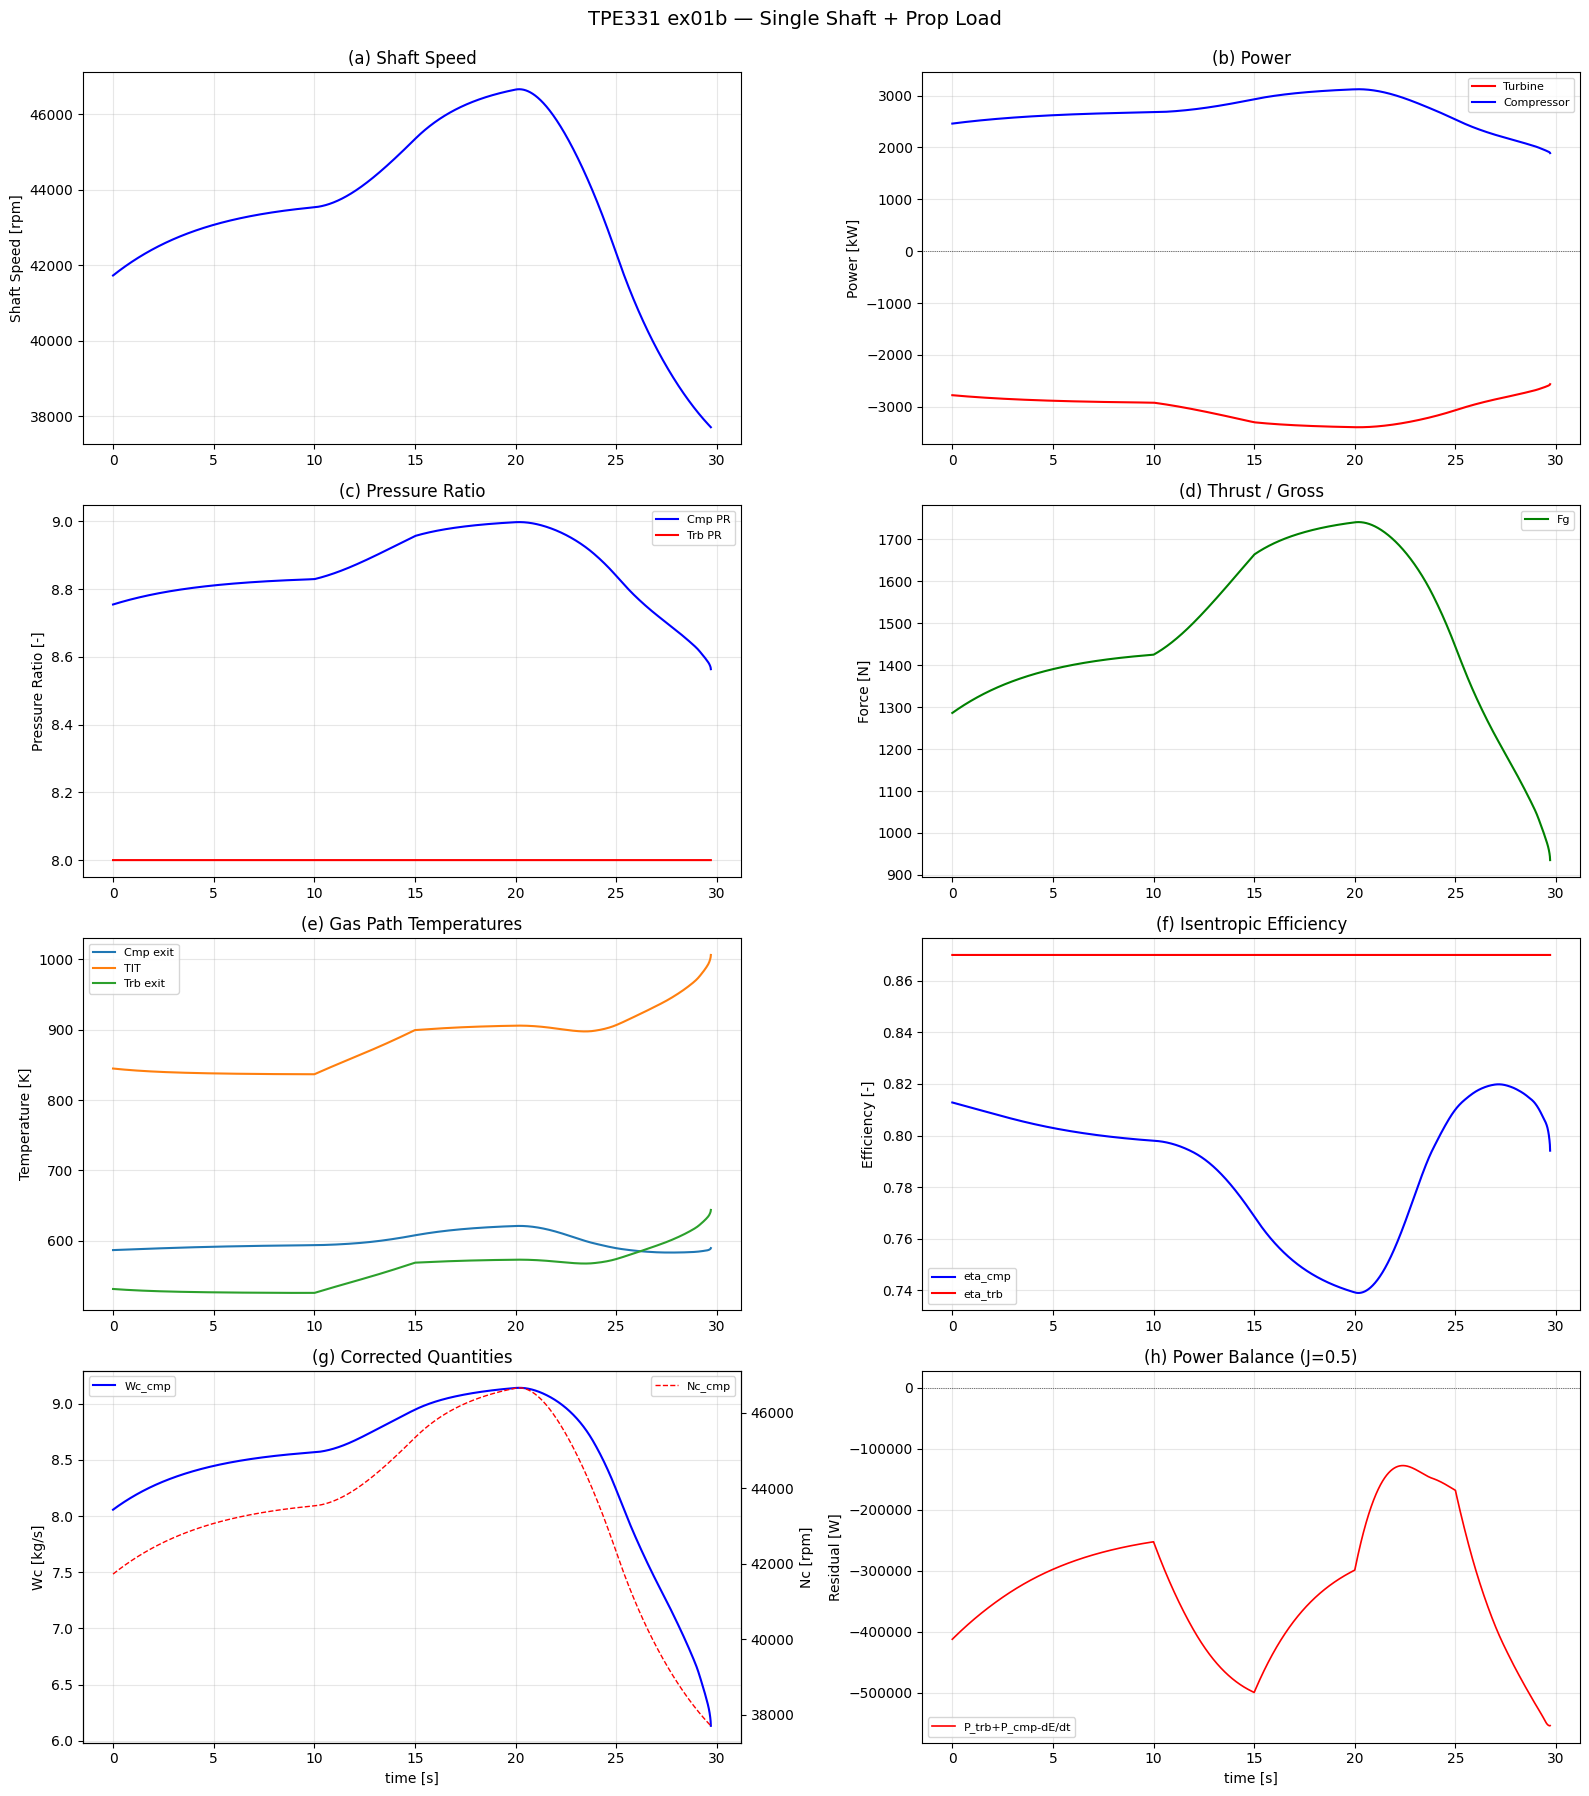

In [23]:
# ── 과도응답 플롯 (ex01b: single-shaft + prop load) ──
fig_b = pp_b.plot_transient(J_shaft=0.5, title="TPE331 ex01b — Single Shaft + Prop Load")

In [24]:
# ── 정량 검증: 파워밸런스 & 정상상태 값 (ex01b) ──
vr_b = pp_b.verify_power_balance(J_shaft=0.5, ss_fraction=0.1)

# 설계점 비교 (축속도 droop 확인)
print("\n--- Design Point Comparison (ex01b) ---")
des_b = {"shaft_rpm": 41730.0, "PR_cmp": 10.0, "eff_cmp": 0.82}
for k, v_des in des_b.items():
    v_sim = vr_b.steady_state.get(k)
    if v_sim is not None:
        err_pct = (v_sim - v_des) / v_des * 100
        print(f"  {k:14s}: design={v_des:.2f}, sim={v_sim:.2f}, err={err_pct:+.2f}%")

# 프로펠러 부하 확인
print("\n--- Prop Load on Turbine Shaft ---")
print(f"  Gear ratio: 20.87")
print(f"  Load (idle→cruise): -23 → -114 N·m")
col_trq = pp_b.find_col(["PropLoad_tau", "PropLoad_flange_tau", "ramp_PropTorque_y"])
if col_trq:
    trq_final = mdf_b[col_trq].iloc[-1]
    print(f"  Final load torque: {trq_final:.1f} N·m")

  TPE331_ex1b — Verification Summary
  Time: 0.000 ~ 29.706 s (2984 steps)
  SS window: last 298 steps

  Steady-state values:
    shaft_rpm     : 38764.8689
    PR_cmp        : 8.6626
    eff_cmp       : 0.8149
    TIT_K         : 957.4369
    Fg_N          : 1117.1626
    P_cmp_kW      : 2100.6775
    P_trb_kW      : -2742.7097

  Power balance: 13.9153% [FAIL]
  Note: |eps_ss| = 13.9153%

--- Design Point Comparison (ex01b) ---
  shaft_rpm     : design=41730.00, sim=38764.87, err=-7.11%
  PR_cmp        : design=10.00, sim=8.66, err=-13.37%
  eff_cmp       : design=0.82, sim=0.81, err=-0.62%

--- Prop Load on Turbine Shaft ---
  Gear ratio: 20.87
  Load (idle→cruise): -23 → -114 N·m


In [25]:
# ── 진단: Cmp_PR 신호 검증 ──
import numpy as np

print("=" * 70)
print("DIAGNOSTIC: Compressor PR signal analysis")
print("=" * 70)

# 1) 어떤 컬럼이 매칭되었나?
col_PR_b = pp_b.find_col(["Cmp_PR"])
col_Wc_b = pp_b.find_col(["Cmp_Wc_1", "Cmp_Wc"])
col_Nc_b = pp_b.find_col(["Cmp_Nc_1", "Cmp_Nc"])
col_Rline_b = pp_b.find_col(["Cmp_Rline", "Rline"])

print(f"\n[Matched columns]")
print(f"  PR    : '{col_PR_b}'")
print(f"  Wc    : '{col_Wc_b}'")
print(f"  Nc    : '{col_Nc_b}'")
print(f"  Rline : '{col_Rline_b}'")

# 2) 모든 PR 관련 컬럼 목록
print(f"\n[All columns containing 'PR' or 'pr']")
for c in sorted(mdf_b.columns):
    if "PR" in c.upper() or "pr" in c:
        vals = mdf_b[c].to_numpy(dtype=float)
        print(f"  {c:40s} min={vals.min():.4f}  max={vals.max():.4f}  mean={vals.mean():.4f}")

# 3) 시뮬레이션 값 통계
print(f"\n[Signal statistics]")
t_b = mdf_b["time"].to_numpy()
print(f"  time : {t_b.min():.3f} ~ {t_b.max():.3f} s  ({len(t_b)} points)")

if col_PR_b:
    pr_vals = mdf_b[col_PR_b].to_numpy(dtype=float)
    print(f"  PR   : min={pr_vals.min():.4f}  max={pr_vals.max():.4f}  mean={pr_vals.mean():.4f}  std={pr_vals.std():.4f}")
    # 마지막 10% (정상상태 추정)
    n_ss = max(1, len(pr_vals) // 10)
    pr_ss = pr_vals[-n_ss:]
    print(f"  PR (last 10%, steady-state): mean={pr_ss.mean():.4f}  std={pr_ss.std():.4f}")

if col_Wc_b:
    wc_vals = mdf_b[col_Wc_b].to_numpy(dtype=float)
    print(f"  Wc   : min={wc_vals.min():.4f}  max={wc_vals.max():.4f}  mean={wc_vals.mean():.4f}")

if col_Nc_b:
    nc_vals = mdf_b[col_Nc_b].to_numpy(dtype=float)
    print(f"  Nc   : min={nc_vals.min():.4f}  max={nc_vals.max():.4f}  mean={nc_vals.mean():.4f}")

if col_Rline_b:
    rl_vals = mdf_b[col_Rline_b].to_numpy(dtype=float)
    print(f"  Rline: min={rl_vals.min():.4f}  max={rl_vals.max():.4f}  mean={rl_vals.mean():.4f}")

# 4) 기대값 vs 실측 비교
print(f"\n[Expected vs Actual]")
print(f"  Map PR range  : 1.5 ~ 15.3 (from table)")
print(f"  Design PR     : 10.0")
if col_PR_b:
    ratio = pr_ss.mean() / 10.0
    print(f"  Sim PR/Design : {ratio:.4f}")
    if abs(ratio - 3.3) < 0.5:
        print(f"  ⚠ PR is ~3.3× design. Possible: signal = p2[Pa]/p1[Pa]?")
        print(f"    If p1=101325 Pa, p2=p1*PR → p2/1e5 ≈ PR...")
        print(f"    Or signal is p2 in bar: {pr_ss.mean()/1e5:.4f} → unlikely")
    elif ratio > 2:
        print(f"  ⚠ PR is {ratio:.1f}× design — abnormal!")

# 5) 압력 관련 컬럼으로 PR 재계산 시도
col_p1 = pp_b.find_col(["Cmp_port_1_p", "port_1_p", "Cmp_fluid_1_p", "Inlet_port_2_p"])
col_p2 = pp_b.find_col(["Cmp_port_2_p", "port_2_p", "Cmp_fluid_2_p"])
print(f"\n[Pressure ports]")
print(f"  p1 col: '{col_p1}'")
print(f"  p2 col: '{col_p2}'")
if col_p1 and col_p2:
    p1 = mdf_b[col_p1].to_numpy(dtype=float)
    p2 = mdf_b[col_p2].to_numpy(dtype=float)
    pr_calc = p2 / p1
    pr_calc_ss = pr_calc[-n_ss:]
    print(f"  p1: {p1.mean():.0f} Pa, p2: {p2.mean():.0f} Pa")
    print(f"  PR_calc = p2/p1: mean={pr_calc_ss.mean():.4f}  (should match map PR)")
    print(f"  → Use this as true PR for map overlay!")

print("\n" + "=" * 70)

DIAGNOSTIC: Compressor PR signal analysis

[Matched columns]
  PR    : 'ex01b1.Cmp_PR'
  Wc    : 'ex01b1.Cmp_Wc_1'
  Nc    : 'ex01b1.Cmp_Nc_1'
  Rline : 'ex01b1.Cmp_Rline'

[All columns containing 'PR' or 'pr']
  ex01b1.Cmp_CmpTbl_WcPReff_NcRline_y_PR   min=8.5635  max=8.9975  mean=8.8567
  ex01b1.Cmp_CmpTbl_WcPReff_NcRline_y_eff  min=0.7390  max=0.8199  mean=0.7882
  ex01b1.Cmp_PR                            min=8.5635  max=8.9975  mean=8.8567
  ex01b1.Cmp_ScalerDesCmp_CmpTbl_WcPReff_NcRline_Des_y_PR min=10.0000  max=10.0000  mean=10.0000
  ex01b1.Cmp_ScalerDesCmp_CmpTbl_WcPReff_NcRline_Des_y_eff min=0.8200  max=0.8200  mean=0.8200
  ex01b1.Cmp_SclCmp_u_PR                   min=8.5635  max=8.9975  mean=8.8567
  ex01b1.Cmp_SclCmp_u_s_PR                 min=1.0000  max=1.0000  mean=1.0000
  ex01b1.Cmp_variablesDes_PR               min=8.5635  max=8.9975  mean=8.8567
  ex01b1.Nzl_PR                            min=1.0651  max=1.1191  mean=1.1016
  ex01b1.Trb_PR                            m

Wc col: ex01b1.Cmp_Wc_1
PR col: ex01b1.Cmp_PR

[Map range]  Wc: 1.62 ~ 9.07 kg/s,  PR: 1.53 ~ 15.30
[Sim range]  Wc: 6.13 ~ 9.14 kg/s,  PR: 8.56 ~ 9.00
[Wc ratio]   sim_mean/design_corr = 1.059


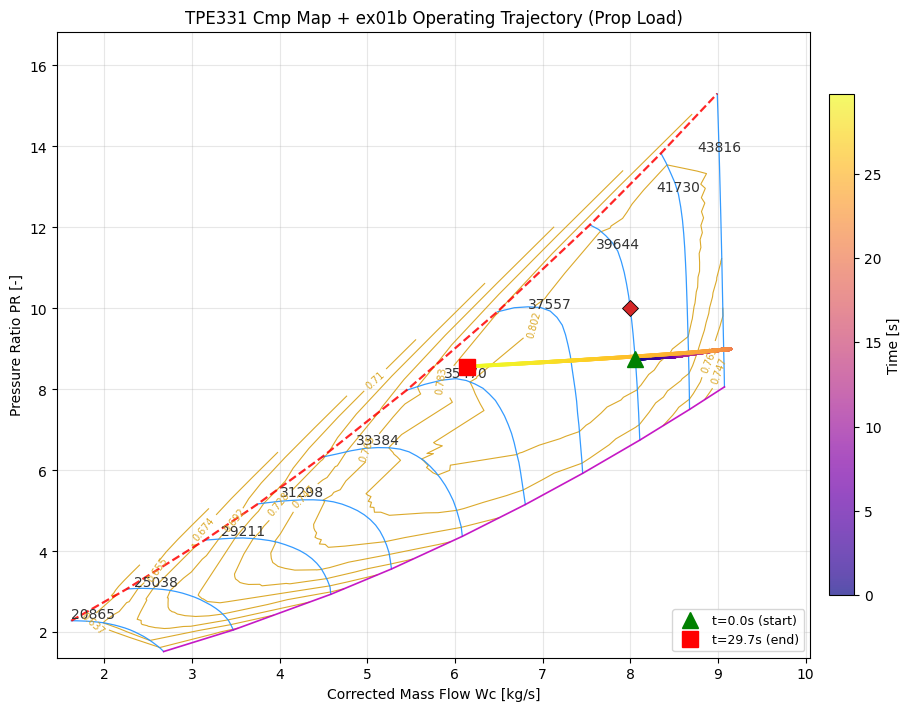


✓ ex01b trajectory: Wc=8.06→6.13, PR=8.75→8.56


In [26]:
# ── 컴프레서 맵 + 시뮬레이션 운전 궤적 오버레이 (ex01b) ──
import numpy as np
import matplotlib.pyplot as plt
from turbomap_plot_utils import plot_compressor_map

# 시뮬레이션에서 Wc, PR 추출
col_Wc_b = pp_b.find_col(["Cmp_Wc_1", "Cmp_Wc"])
col_PR_b = pp_b.find_col(["Cmp_PR"])

print(f"Wc col: {col_Wc_b}")
print(f"PR col: {col_PR_b}")

if col_Wc_b and col_PR_b:
    t_sim_b = mdf_b["time"].to_numpy()
    Wc_sim_b = mdf_b[col_Wc_b].to_numpy(dtype=float)
    PR_sim_b = mdf_b[col_PR_b].to_numpy(dtype=float)

    # ─── 진단: 시뮬레이션 vs 맵 범위 비교 ───
    pr_map_min = scaled["pr_scaled"].min()
    pr_map_max = scaled["pr_scaled"].max()
    wc_map_min = scaled["wc_scaled_corr"].min()
    wc_map_max = scaled["wc_scaled_corr"].max()
    print(f"\n[Map range]  Wc: {wc_map_min:.2f} ~ {wc_map_max:.2f} kg/s,  PR: {pr_map_min:.2f} ~ {pr_map_max:.2f}")
    print(f"[Sim range]  Wc: {Wc_sim_b.min():.2f} ~ {Wc_sim_b.max():.2f} kg/s,  PR: {PR_sim_b.min():.2f} ~ {PR_sim_b.max():.2f}")

    # ─── Wc가 actual flow일 경우 corrected flow로 변환 ───
    # CmpCharTable00의 Wc_1 출력이 actual이면 보정 필요
    # Wc_corr = Wc_actual * sqrt(T1/Tref) / (P1/Pref)
    # ISA SL: T1=288.15K, p1=101325Pa → correction factor = 1.0
    # 만약 sim Wc가 map Wc 범위의 ~10배이면 actual flow일 가능성 높음
    wc_ratio = Wc_sim_b.mean() / scaled["wc_target_corr"] if scaled["wc_target_corr"] > 0 else 1.0
    print(f"[Wc ratio]   sim_mean/design_corr = {wc_ratio:.3f}")

    if wc_ratio > 5:
        # actual flow → corrected flow 변환 시도
        from turbomap_data_utils import T_REF, P_REF
        corr = np.sqrt(TPE331_CMP["T1_des"] / T_REF) / (TPE331_CMP["p1_des"] / P_REF)
        Wc_plot = Wc_sim_b * corr
        print(f"  ⚠ Wc appears to be actual flow. Applying correction factor={corr:.4f}")
    else:
        Wc_plot = Wc_sim_b

    # 1) 컴프레서 맵 그리기
    fig_ov_b, ax_ov_b = plot_compressor_map(
        scaled["wc_scaled_corr"],
        scaled["pr_scaled"],
        scaled["eta_scaled"],
        scaled["nc"],
        NmechDes=41730.0,
        design_point={"Wc": scaled["wc_target_corr"], "PR": TPE331_CMP["PRdes"]},
        title="TPE331 Cmp Map + ex01b Operating Trajectory (Prop Load)",
    )

    # 2) 시뮬레이션 궤적 오버레이 (시간 색상 코딩)
    sc_b = ax_ov_b.scatter(
        Wc_plot, PR_sim_b, c=t_sim_b, cmap="plasma", s=8, zorder=5, alpha=0.7, edgecolors="none"
    )
    cbar_b = plt.colorbar(sc_b, ax=ax_ov_b, shrink=0.8, pad=0.02)
    cbar_b.set_label("Time [s]")

    # 시작/종료점 강조
    ax_ov_b.plot(Wc_plot[0], PR_sim_b[0], "g^", ms=12, zorder=6, label=f"t={t_sim_b[0]:.1f}s (start)")
    ax_ov_b.plot(Wc_plot[-1], PR_sim_b[-1], "rs", ms=12, zorder=6, label=f"t={t_sim_b[-1]:.1f}s (end)")
    ax_ov_b.legend(loc="lower right", fontsize=9)

    # 3) 축 범위: 맵+궤적 모두 포함하도록 조정
    all_wc = np.concatenate([scaled["wc_scaled_corr"].ravel(), Wc_plot])
    all_pr = np.concatenate([scaled["pr_scaled"].ravel(), PR_sim_b])
    ax_ov_b.set_xlim(all_wc.min() * 0.9, all_wc.max() * 1.1)
    ax_ov_b.set_ylim(max(0.5, all_pr.min() * 0.9), all_pr.max() * 1.1)

    plt.show()
    print(f"\n✓ ex01b trajectory: Wc={Wc_plot[0]:.2f}→{Wc_plot[-1]:.2f}, PR={PR_sim_b[0]:.2f}→{PR_sim_b[-1]:.2f}")
    if PR_sim_b.max() > pr_map_max:
        print(f"  ⚠ Sim PR ({PR_sim_b.max():.2f}) exceeds map max ({pr_map_max:.2f}) — operating outside mapped region!")
else:
    print("⚠ Wc_1 또는 PR 컬럼이 mdf_b에 없습니다.")
    for c in sorted(mdf_b.columns):
        if c != "time":
            print(f"  {c}")

In [27]:
# ── 진단: SLS 결과 상세 분석 ──
import numpy as np

print("=" * 70)
print("SLS DIAGNOSTIC (alt=0, MN=0)")
print("=" * 70)

# 시간 범위
print(f"\n[Time]  {t_sim_b.min():.2f} ~ {t_sim_b.max():.2f} s  ({len(t_sim_b)} pts)")

# 압력 (p1, p2)
if col_p1 and col_p2:
    p1_vals = mdf_b[col_p1].to_numpy(dtype=float)
    p2_vals = mdf_b[col_p2].to_numpy(dtype=float)
    print(f"\n[Pressures]")
    print(f"  p1 (inlet) : min={p1_vals.min():.0f}  max={p1_vals.max():.0f}  end={p1_vals[-1]:.0f} Pa")
    print(f"  p2 (exit)  : min={p2_vals.min():.0f}  max={p2_vals.max():.0f}  end={p2_vals[-1]:.0f} Pa")
    print(f"  PR=p2/p1   : min={pr_calc.min():.2f}  max={pr_calc.max():.2f}  end={pr_calc[-1]:.2f}")
    print(f"  Expected p1 @ SLS: 101,325 Pa")
    if p1_vals[-1] < 80000:
        print(f"  ⚠ p1 too low! Model may not have been re-simulated with alt=0, MN=0")

# Rline
if col_Rline_b:
    print(f"\n[Rline]")
    print(f"  min={rl_vals.min():.4f}  max={rl_vals.max():.4f}  end={rl_vals[-1]:.4f}")
    print(f"  Expected: 0 ~ 1.0 (map range)")
    if rl_vals.max() > 1.0:
        print(f"  ⚠ Rline > 1.0 → table extrapolation (surge region)")

# Nc (corrected speed or rpm)
if col_Nc_b:
    print(f"\n[Nc / Speed]")
    print(f"  min={nc_vals.min():.2f}  max={nc_vals.max():.2f}  end={nc_vals[-1]:.2f}")
    # Nc가 rpm이면 → 정규화
    if nc_vals.mean() > 100:
        nc_norm = nc_vals / 41730.0
        print(f"  Nc_normalized (÷41730): min={nc_norm.min():.4f}  max={nc_norm.max():.4f}  end={nc_norm[-1]:.4f}")
        print(f"  Map Nc range: 0.50 ~ 1.05")

# PR (from Cmp signal vs calculated)
print(f"\n[PR comparison]")
print(f"  Cmp_PR signal: min={pr_vals.min():.2f}  max={pr_vals.max():.2f}  end={pr_vals[-1]:.2f}")
print(f"  p2/p1 calc   : min={pr_calc.min():.2f}  max={pr_calc.max():.2f}  end={pr_calc[-1]:.2f}")

# Wc
if col_Wc_b:
    print(f"\n[Wc]")
    print(f"  min={wc_vals.min():.4f}  max={wc_vals.max():.4f}  end={wc_vals[-1]:.4f}")

# 축 속도
if 'rpm_b' in dir():
    print(f"\n[Shaft]")
    print(f"  RPM: min={rpm_b.min():.0f}  max={rpm_b.max():.0f}  end={rpm_b[-1]:.0f}")

print(f"\n{'='*70}")
print("VERDICT:")
if col_p1 and p1_vals[-1] > 80000:
    print("  ✓ p1 is near SLS (101kPa) — flight condition fix applied")
else:
    print("  ✗ p1 too low — simulation may not reflect alt=0, MN=0 patch!")
if col_Rline_b and rl_vals.max() <= 1.05:
    print("  ✓ Rline within map range")
elif col_Rline_b:
    print(f"  ✗ Rline up to {rl_vals.max():.2f} — still extrapolating!")
    print("    Cause: downstream boundary (Trb+Nzl) not matching compressor capacity")
    print("    Fix options:")
    print("      1. Reduce fuel → less TIT → less turbine power → shaft slows → PR drops")
    print("      2. Increase prop load → shaft slows faster")
    print("      3. Match TrbCharFixed00 PR to cycle balance (PR_trb ≈ PR_cmp)")
    print("      4. Use TrbCharTable00 instead of TrbCharFixed00 (self-regulating)")
print("=" * 70)

SLS DIAGNOSTIC (alt=0, MN=0)

[Time]  0.00 ~ 29.71 s  (2984 pts)

[Pressures]
  p1 (inlet) : min=100817  max=100817  end=100817 Pa
  p2 (exit)  : min=863348  max=907107  end=863348 Pa
  PR=p2/p1   : min=8.56  max=9.00  end=8.56
  Expected p1 @ SLS: 101,325 Pa

[Rline]
  min=0.1118  max=0.8583  end=0.8583
  Expected: 0 ~ 1.0 (map range)

[Nc / Speed]
  min=37709.88  max=46662.47  end=37709.88
  Nc_normalized (÷41730): min=0.9037  max=1.1182  end=0.9037
  Map Nc range: 0.50 ~ 1.05

[PR comparison]
  Cmp_PR signal: min=8.56  max=9.00  end=8.56
  p2/p1 calc   : min=8.56  max=9.00  end=8.56

[Wc]
  min=6.1343  max=9.1409  end=6.1343

[Shaft]
  RPM: min=41662  max=41829  end=41662

VERDICT:
  ✓ p1 is near SLS (101kPa) — flight condition fix applied
  ✓ Rline within map range


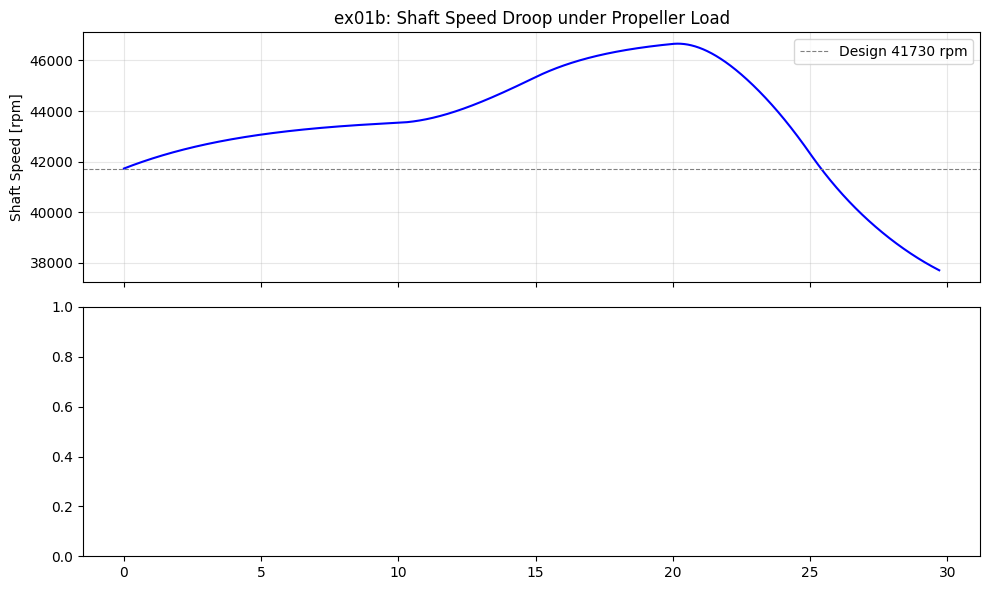


✓ Shaft speed: 41730 → 37711 rpm (droop: -9.63%)


In [28]:
# ── 축 속도 + 프로펠러 부하 시계열 (ex01b 고유: 부하 droop 확인) ──
import numpy as np
import matplotlib.pyplot as plt

fig_droop, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# 축 속도 (RPM)
t_b = mdf_b["time"].to_numpy()
col_w = pp_b.find_col(["Shaft_w", "Shaft_flange_a_w", "ShaftGG_w"])
if col_w:
    w_rad = mdf_b[col_w].to_numpy(dtype=float)
    rpm_b = w_rad * 60 / (2 * np.pi)
    ax1.plot(t_b, rpm_b, "b-", lw=1.5)
    ax1.axhline(41730, color="gray", ls="--", lw=0.8, label="Design 41730 rpm")
    ax1.set_ylabel("Shaft Speed [rpm]")
    ax1.legend(loc="best")
    ax1.set_title("ex01b: Shaft Speed Droop under Propeller Load")
    ax1.grid(True, alpha=0.3)

# 프로펠러 토크
col_trq_b = pp_b.find_col(["ramp_PropTorque_y", "PropLoad_tau", "PropLoad_flange_tau"])
if col_trq_b:
    trq_b = mdf_b[col_trq_b].to_numpy(dtype=float)
    ax2.plot(t_b, trq_b, "r-", lw=1.5)
    ax2.set_ylabel("Prop Torque (turbine-side) [N·m]")
    ax2.set_xlabel("Time [s]")
    ax2.grid(True, alpha=0.3)
    ax2.axhline(-114, color="gray", ls="--", lw=0.8, label="Cruise -114 N·m")
    ax2.axhline(-23, color="gray", ls=":", lw=0.8, label="Idle -23 N·m")
    ax2.legend(loc="best")

plt.tight_layout()
plt.show()

if col_w:
    droop_pct = (rpm_b[-1] - 41730) / 41730 * 100
    print(f"\n✓ Shaft speed: {rpm_b[0]:.0f} → {rpm_b[-1]:.0f} rpm (droop: {droop_pct:+.2f}%)")